In [1]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
from turbos.sim.p3d.p3d_2 import P3D
import matplotlib.pyplot as plt

In [3]:
run = P3D(
    "/archive/tulasi/149p6_rs",
    filenum="000",
)

ds = run.load_xarray(
    0,
    variables=[
        "B",
        "ue",
        "Pe",
        "ne",
    ],
)
print(ds)

<xarray.Dataset> Size: 2GB
Dimensions:  (x: 4096, y: 4096, c: 3, j: 3, i: 3)
Coordinates:
  * x        (x) float64 33kB 0.0 0.03651 0.07303 0.1095 ... 149.5 149.5 149.5
  * y        (y) float64 33kB 0.0 0.03651 0.07303 0.1095 ... 149.5 149.5 149.5
  * c        (c) <U1 12B 'x' 'y' 'z'
  * j        (j) <U1 12B 'x' 'y' 'z'
  * i        (i) <U1 12B 'x' 'y' 'z'
Data variables:
    B        (x, y, c) float64 403MB -0.1983 0.2484 0.9533 ... 0.2602 0.9486
    ue       (x, y, c) float64 403MB -0.08108 0.1369 0.1796 ... 0.1464 0.2062
    Pe       (x, y, i, j) float64 1GB 0.2916 -0.005824 ... 0.01334 0.3589
    ne       (x, y) float64 134MB 1.027 1.019 1.01 1.028 ... 1.024 1.023 1.032
Attributes:
    time:      0.0
    run:       149p6_rs
    snapshot:  0
    format:    movie


In [4]:
from turbos.pressure_strain import pressure_strain
PS = pressure_strain(ds['Pe'], ds['ue'])


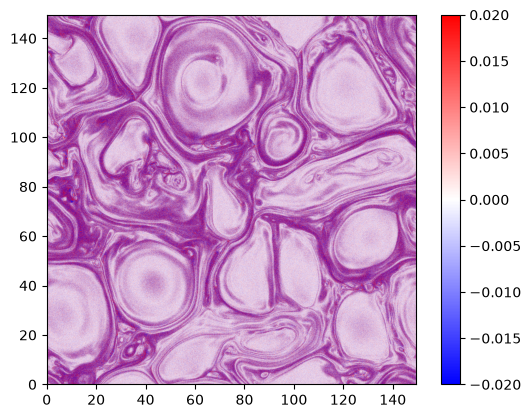

In [5]:
import matplotlib.pyplot as plt
plt.imshow(PS['PiD'], cmap = 'bwr', origin='lower', extent=[ds.x.values[0], ds.x.values[-1], ds.y.values[0], ds.y.values[-1]])
plt.clim(-0.02, 0.02)
plt.colorbar()
plt.show()